#pull data with pandas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/dental_procedures.csv')
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')

Loaded: 2000 rows × 16 columns


In [ ]:
df.info()

In [ ]:
df.describe()

#verify data pulled correctly

In [ ]:
df.head()

In [ ]:
df.tail()

#noticed data wasnt sorted; sorting now

In [ ]:
df.sort_values(by='date', inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

#how many of each procedure were performed?

In [3]:
print('Procedure names and counts:')
print(df['procedure_name'].value_counts())

Procedure names and counts:
procedure_name
Adult Cleaning                374
Periodic Oral Exam            254
Bitewing X-rays (4)           172
Composite Filling (1 surf)    157
Child Cleaning                120
Comprehensive Oral Exam       116
Fluoride Treatment            105
Amalgam Filling (1 surf)      100
Simple Extraction              91
Full Mouth X-rays              87
Porcelain Crown                77
Perio Maintenance              62
Periodontal Scaling (quad)     55
Core Buildup                   42
Surgical Extraction            40
Root Canal - Molar             38
Root Canal - Anterior          37
Comprehensive Ortho            35
Implant Fixture                19
Complete Upper Denture         19
Name: count, dtype: int64


In [6]:
vol_data = df['category'].value_counts().sort_values(ascending=False)

axes[0].bar(vol_data.index, vol_data.values, color=LT_BLUE, edgecolor='none')
axes[0].set_xlabel('CATEGORY', fontsize=7, fontfamily='monospace')
axes[0].set_ylabel('PROCEDURES', fontsize=7, fontfamily='monospace')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].grid(False)
panel_title(axes[0], '01  PROCEDURE VOLUME BY CATEGORY')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

#categories

In [ ]:
print('Category and counts:')
print(df['category'].value_counts())

#total revenue generated by category

In [7]:
df.groupby('category')['procedure_fee'].sum().sort_values(ascending=False)

category
Orthodontics      180875
Restorative       158005
Endodontics        81026
Preventive         59475
Diagnostic         54041
Implants           45918
Prosthodontics     30980
Oral Surgery       29665
Periodontics       23967
Name: procedure_fee, dtype: int64

#average revenue per procedure by category

In [8]:
df.groupby('category')['procedure_fee'].mean().sort_values(ascending=False)

category
Orthodontics      5167.857143
Implants          2416.736842
Prosthodontics    1630.526316
Endodontics       1080.346667
Restorative        420.226064
Oral Surgery       226.450382
Periodontics       204.846154
Preventive          99.290484
Diagnostic          85.915739
Name: procedure_fee, dtype: float64

#so I can see the surgeries are bringing in the most money, but they also take the most time. are they still the most efficient after taking time_spent into account?

In [ ]:
# revenue per minute of chair time
df['revenue_per_min'] = df['procedure_fee'] / df['duration_min']

# now average revenue per minute by category
df[df['duration_min'] > 0].groupby('category')['revenue_per_min'].mean().sort_values(ascending=False)

#is there a certain time of year where dental work is more common?

In [ ]:
df.groupby(['month', 'category']).size().unstack(fill_value=0)

#translating code to a heatmap to read more easily

In [ ]:
# procedures per month by category
heatmap_data = df.groupby(['month', 'category']).size().unstack(fill_value=0)
# unstack() pivots the month into columns — creates a month × category matrix

# Rename columns to month abbreviations
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heatmap_data.index = [month_names[m-1] for m in heatmap_data.index]
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='gray',
    ax=ax,
    cbar_kws={'label': 'Number of Procedures'}
)
ax.set_title('Procedures by Month and Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

#what age groups book more appointments

In [ ]:
df.groupby('patient_age_group').size().sort_values(ascending=False)

#what groups have a higher chance of accepting treatment?

In [ ]:
df.groupby('patient_age_group').agg(
    total=('treatment_accepted', 'count'),
    accepted=('treatment_accepted', 'sum'),
).assign(acceptance_rate=lambda x: x['accepted'] / x['total'] * 100).sort_values(by='acceptance_rate', ascending=False)

#Seniors show lowest acceptance rate (79.4) likely driven by historical distrust of dentistry, fixed income constraints, and anxiety from older less comfortable dental experiences. Target demographic for trust-building patient communication strategies.

#final dashboard to compile everything learned today

C:\Users\Hunter\AppData\Local\Temp\ipykernel_5580\3116236014.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(vol_data.index, rotation=45, ha='right', fontsize=6)
C:\Users\Hunter\AppData\Local\Temp\ipykernel_5580\3116236014.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(vol_data.index, rotation=45, ha='right', fontsize=6)
C:\Users\Hunter\AppData\Local\Temp\ipykernel_5580\3116236014.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g['procedure_fee'].sum() / g[

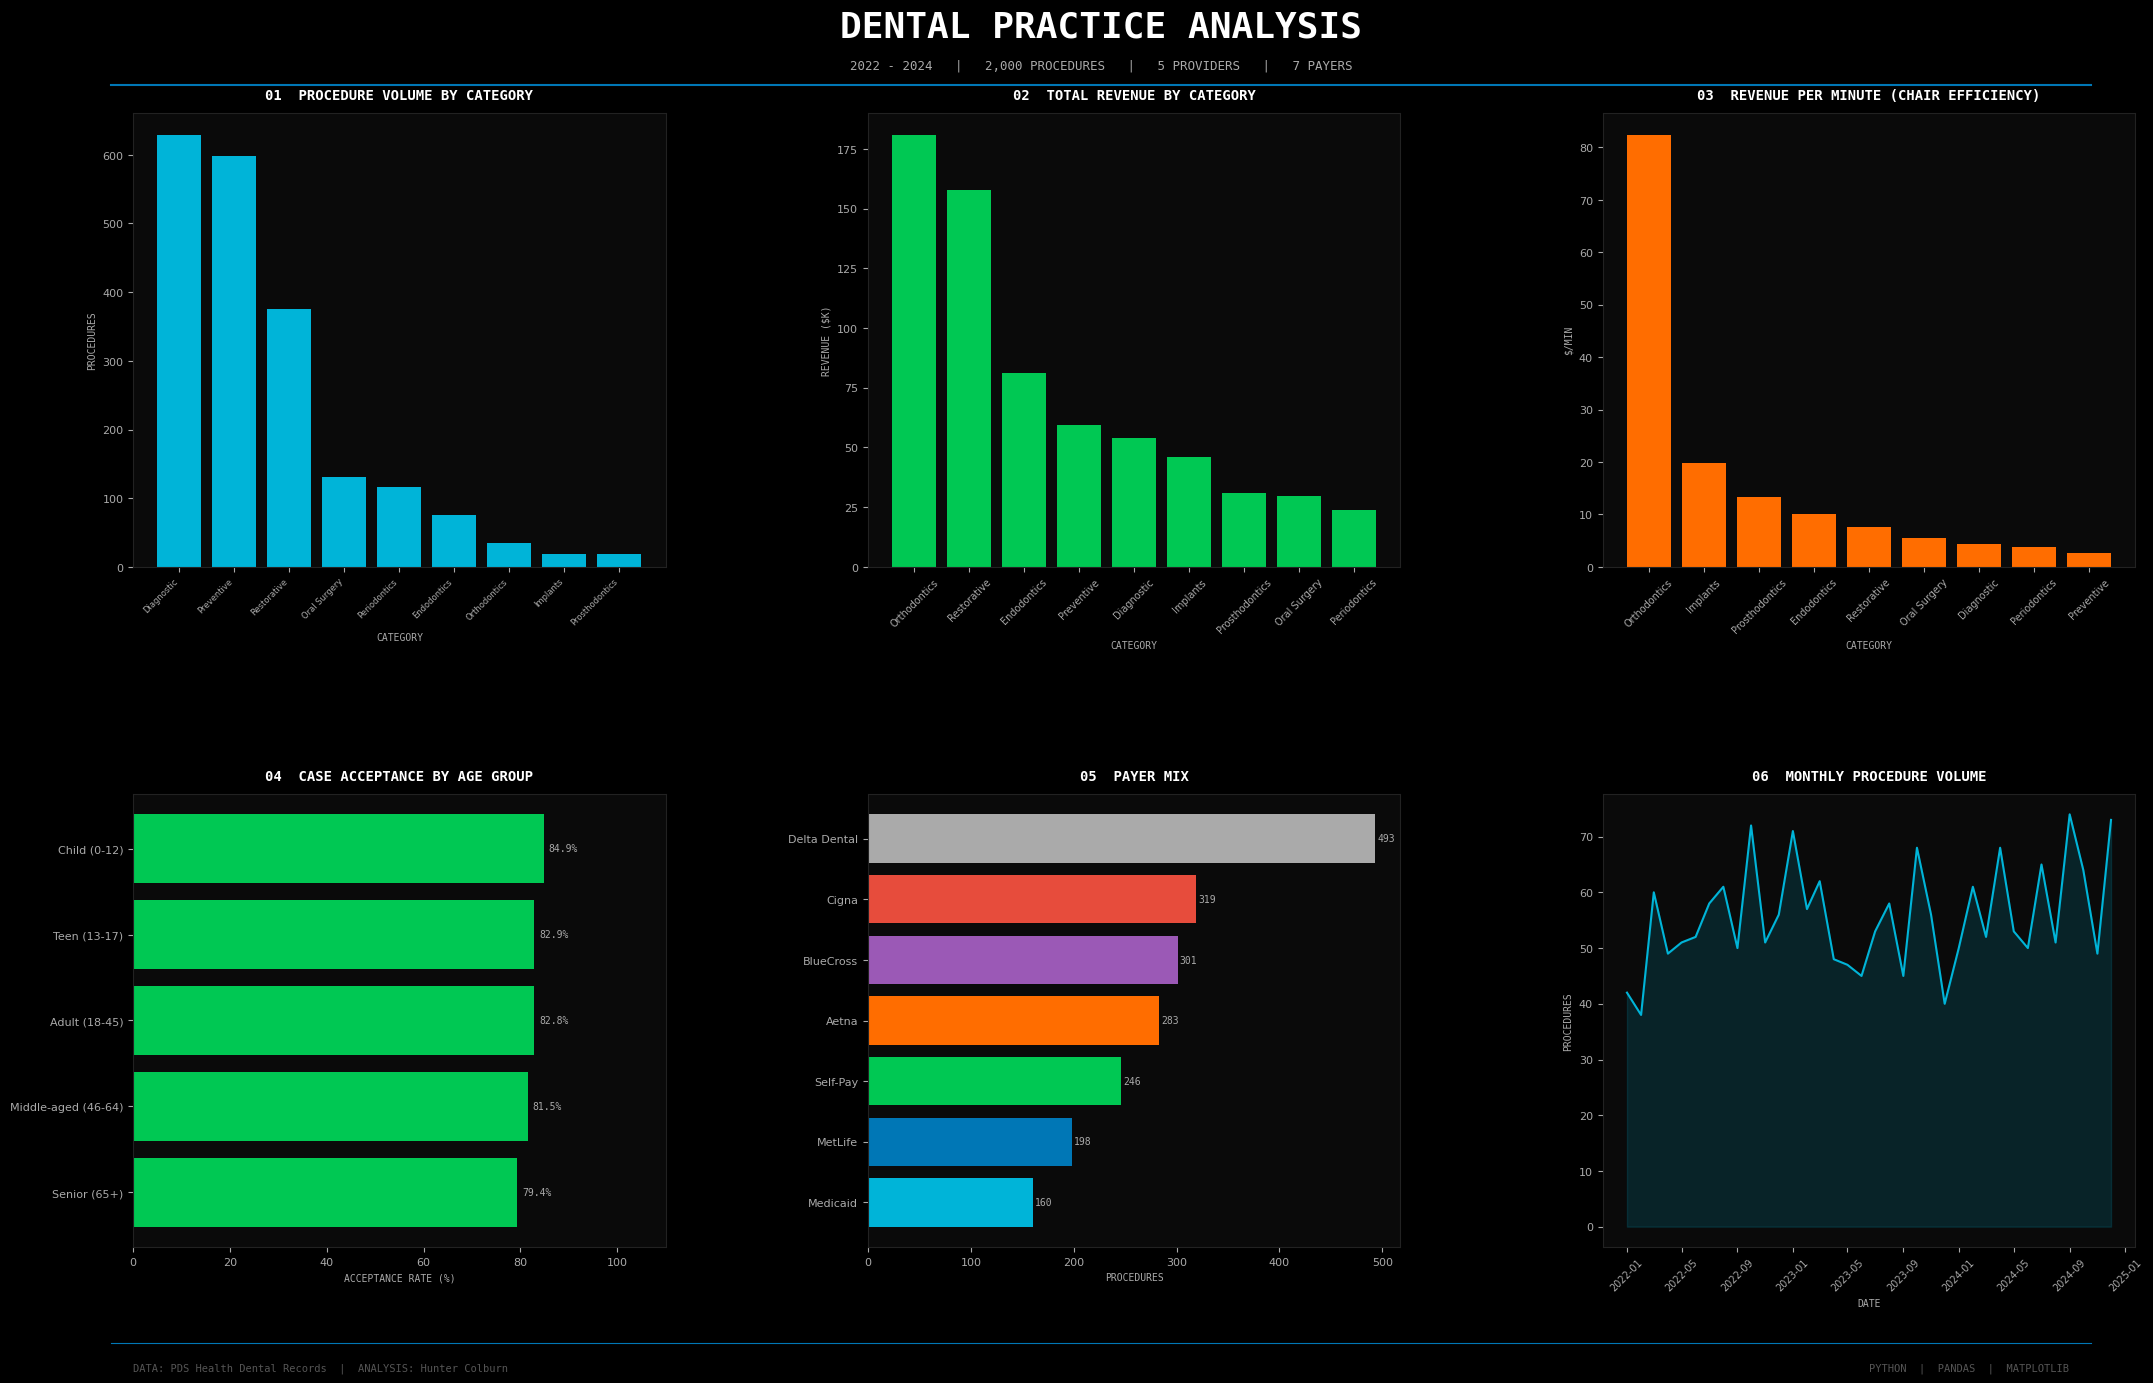

✅ Dashboard saved


In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.style.use('dark_background')
BLACK='#000000'; WHITE='#ffffff'; BLUE='#0077b6'; LT_BLUE='#00b4d8'
GRAY='#555555'; LT_GRAY='#aaaaaa'; GREEN='#00c853'; ORANGE='#ff6d00'; RED='#d50000'

fig = plt.figure(figsize=(22, 14), facecolor=BLACK)
fig.text(0.5, 0.965, 'DENTAL PRACTICE ANALYSIS', ha='center', fontsize=26, fontweight='bold', color=WHITE, fontfamily='monospace')
fig.text(0.5, 0.942, '2022 - 2024   |   2,000 PROCEDURES   |   5 PROVIDERS   |   7 PAYERS', ha='center', fontsize=9, color=LT_GRAY, fontfamily='monospace')
line = plt.Line2D([0.05, 0.95], [0.930, 0.930], transform=fig.transFigure, color=BLUE, linewidth=1.5)
fig.add_artist(line)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38, left=0.06, right=0.97, top=0.91, bottom=0.10)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]
for ax in axes:
    ax.set_facecolor('#0a0a0a')
    ax.tick_params(colors=LT_GRAY, labelsize=8)
    ax.xaxis.label.set_color(LT_GRAY); ax.yaxis.label.set_color(LT_GRAY)
    for spine in ax.spines.values(): spine.set_edgecolor('#222222')

def panel_title(ax, title):
    ax.set_title(title, color=WHITE, fontsize=10, fontweight='bold', pad=10, fontfamily='monospace')

# ── Panel 1: Procedure volume by category ────────────────────────────────────
vol_data = df['category'].value_counts().sort_values(ascending=False)
axes[0].bar(vol_data.index, vol_data.values, color=LT_BLUE, edgecolor='none')
axes[0].set_xlabel('CATEGORY', fontsize=7, fontfamily='monospace')
axes[0].set_ylabel('PROCEDURES', fontsize=7, fontfamily='monospace')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].grid(False)
panel_title(axes[0], '01  PROCEDURE VOLUME BY CATEGORY')
axes[0].set_xticklabels(vol_data.index, rotation=45, ha='right', fontsize=6)

# ── Panel 2: Total revenue by category ───────────────────────────────────────
rev_data = df.groupby('category')['procedure_fee'].sum().sort_values(ascending=False)
axes[1].bar(rev_data.index, rev_data.values / 1000, color=GREEN, edgecolor='none')
axes[1].set_xlabel('CATEGORY', fontsize=7, fontfamily='monospace')
axes[1].set_ylabel('REVENUE ($K)', fontsize=7, fontfamily='monospace')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].grid(False)
panel_title(axes[1], '02  TOTAL REVENUE BY CATEGORY')
axes[0].set_xticklabels(vol_data.index, rotation=45, ha='right', fontsize=6)

# ── Panel 3: Revenue per minute by category ───────────────────────────────────
rpm_data = (df[df['duration_min'] > 0]
            .groupby('category')
            .apply(lambda g: g['procedure_fee'].sum() / g['duration_min'].sum())
            .sort_values(ascending=False))
axes[2].bar(rpm_data.index, rpm_data.values, color=ORANGE, edgecolor='none')
axes[2].set_xlabel('CATEGORY', fontsize=7, fontfamily='monospace')
axes[2].set_ylabel('$/MIN', fontsize=7, fontfamily='monospace')
axes[2].tick_params(axis='x', rotation=45, labelsize=7)
axes[2].grid(False)
panel_title(axes[2], '03  REVENUE PER MINUTE (CHAIR EFFICIENCY)')
axes[0].set_xticklabels(vol_data.index, rotation=45, ha='right', fontsize=6)

# ── Panel 4: Age group acceptance rate ───────────────────────────────────────
accept_data = (df.groupby('patient_age_group')['treatment_accepted']
               .mean()
               .mul(100)
               .sort_values(ascending=True))
colors_accept = [GREEN if v >= 70 else ORANGE if v >= 50 else RED for v in accept_data.values]
axes[3].barh(accept_data.index, accept_data.values, color=colors_accept, edgecolor='none')
axes[3].set_xlabel('ACCEPTANCE RATE (%)', fontsize=7, fontfamily='monospace')
axes[3].set_xlim(0, 110)
for i, v in enumerate(accept_data.values):
    axes[3].text(v + 1, i, f'{v:.1f}%', va='center', color=LT_GRAY, fontsize=7, fontfamily='monospace')
axes[3].grid(False)
panel_title(axes[3], '04  CASE ACCEPTANCE BY AGE GROUP')

# ── Panel 5: Payer mix ────────────────────────────────────────────────────────
payer_data = df['payer'].value_counts().sort_values(ascending=True)
payer_colors = [LT_BLUE, BLUE, GREEN, ORANGE, '#9b59b6', '#e74c3c', LT_GRAY]
axes[4].barh(payer_data.index, payer_data.values, color=payer_colors[:len(payer_data)], edgecolor='none')
axes[4].set_xlabel('PROCEDURES', fontsize=7, fontfamily='monospace')
for i, v in enumerate(payer_data.values):
    axes[4].text(v + 2, i, str(v), va='center', color=LT_GRAY, fontsize=7, fontfamily='monospace')
axes[4].grid(False)
panel_title(axes[4], '05  PAYER MIX')

# ── Panel 6: Monthly procedure volume ────────────────────────────────────────
df['date'] = pd.to_datetime(df['date'])
monthly = df.groupby(df['date'].dt.to_period('M')).size()
monthly.index = monthly.index.to_timestamp()
axes[5].plot(monthly.index, monthly.values, color=LT_BLUE, linewidth=1.5)
axes[5].fill_between(monthly.index, monthly.values, alpha=0.15, color=LT_BLUE)
axes[5].set_xlabel('DATE', fontsize=7, fontfamily='monospace')
axes[5].set_ylabel('PROCEDURES', fontsize=7, fontfamily='monospace')
axes[5].tick_params(axis='x', rotation=45, labelsize=7)
axes[5].grid(False)
panel_title(axes[5], '06  MONTHLY PROCEDURE VOLUME')

# ── Footer ────────────────────────────────────────────────────────────────────
line2 = plt.Line2D([0.05, 0.95], [0.032, 0.032], transform=fig.transFigure, color=BLUE, linewidth=0.8)
fig.add_artist(line2)
fig.text(0.06, 0.012, 'DATA: PDS Health Dental Records  |  ANALYSIS: Hunter Colburn', fontsize=7.5, color=GRAY, fontfamily='monospace')
fig.text(0.94, 0.012, 'PYTHON  |  PANDAS  |  MATPLOTLIB', fontsize=7.5, color=GRAY, fontfamily='monospace', ha='right')

plt.savefig('../outputs/dental_dashboard.png', dpi=180, bbox_inches='tight', facecolor=BLACK)
plt.show()
print('✅ Dashboard saved')